In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import os

from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_29333/4203592361.py:43: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
### Figure out loading for patch files
### Add saving of time arrays 

def load_spe1_data(data_path, lpf_fs, npx_fs, all_patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path):
    
    lfp_one_ms = int(lfp_fs / 1000)
    
    npx_one_ms = int(npx_fs/1000)
    
    #loop through lfp recording folder
    for filename in tqdm(os.listdir(data_path)):

        recfile = os.path.join(data_path, filename)

        if recfile.endswith('.bin'):

            #get cell number 
            cell_num = recfile.split('_')[3].split('/')[1]
            file_type = recfile.split('_')[4]
            
   
            
            #if neuropixel file, figure out if lfp or spike file
            if file_type == "npx":
                file_type = recfile.split('_')[5].split('.')[0]
            
            print(file_type)
            print(recfile)
            if cell_num in cell_ids:
                
                #if lfp file 

                if file_type == 'lfp':
                  
                    #Load LFP data
                    lfp_recording = np.memmap(recfile, mode = 'r', dtype=np.int16, order = 'C')
                    lfp_samples = int(len(lfp_recording)/npx_channels)
                    lfp_recording = lfp_recording.reshape((lfp_samples, npx_channels), order = 'F')
                    lfp_recording = lfp_recording[:, npx_patch_channel]
                    lfp_recording = np.asarray(lfp_recording)
                    lfp_recording = lfp_recording - np.mean(lfp_recording) # de-mean
                    # # filter the LFP data
                    lfp_filt = butter_bandpass(lfp_recording, fs=lfp_fs, filt_freq=[0.1, 250], order=4)

                    lfp_times = np.arange(0, np.shape(lfp_recording)[0]) / lfp_one_ms # in ms instead of sec
                    
                    np.save(out_lfp_path + cell_num + '_lfp_filt.npy', lfp_filt)

                #if patch file
                
                if file_type == 'patch':
                    
                    
                    #get patch fs fot that cell
                    patch_fs = all_patch_fs[cell_num]
                    patch_one_ms = int(patch_fs/1000)
                    #get patch data 
                    patch_recording = np.fromfile(recfile, dtype='float64')
                    patch_recording = np.asarray(patch_recording)
                    #patch_recording = -patch_recording # positive up


                    patch_times = np.arange(0, np.shape(patch_recording)[0]) / patch_one_ms # in ms instead of sec

                    # filter the patch data
                    patch_filt = butter_bandpass(patch_recording, fs=patch_fs, filt_freq=[10, 25000], order=4)
        
                    np.save(out_patch_path + cell_num + 'patch_filt.npy', patch_filt)
                
                #if npx spiking file 
                
                if file_type == 'raw-001':
                    
                    # load npx data
                    npx_recording = np.memmap(recfile, mode = 'r', dtype=np.int16, order = 'C')
                    npx_samples = int(len(npx_recording)/npx_channels)
                    npx_recording = npx_recording.reshape((npx_channels, npx_samples), order = 'F')
                    npx_recording = npx_recording[npx_patch_channel, :]
                    npx_recording = np.asarray(npx_recording)
                    
                    
                    npx_times = np.arange(0, np.shape(npx_recording)[0]) / npx_one_ms # in ms instead of sec
                    # filter the neuropixels data
                    npx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)
                    np.save(out_npx_path + cell_num + 'npx_filt.npy', npx_filt)

                







In [5]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [6]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = get_patch_fs_metadata(metadata_dir, 42)
patch_fs_c14 = get_patch_fs_metadata(metadata_dir, 14)

patch_fs = {'c42':patch_fs_c42, 'c14':patch_fs_c14}


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [7]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c14', 'c42']

In [8]:
load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)


  0%|          | 0/20 [00:00<?, ?it/s]

lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c14_npx_lfp.bin
lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c8_npx_lfp.bin
patch
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c14_patch_ch1.bin
lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c18_npx_lfp.bin
lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c45_npx_lfp.bin
lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c7_npx_lfp.bin
lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/c20_npx_lfp.bin
lfp
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordin

### Look at neuropixel LFP PSDs for all "good" cells

  0%|          | 0/7 [00:00<?, ?it/s]

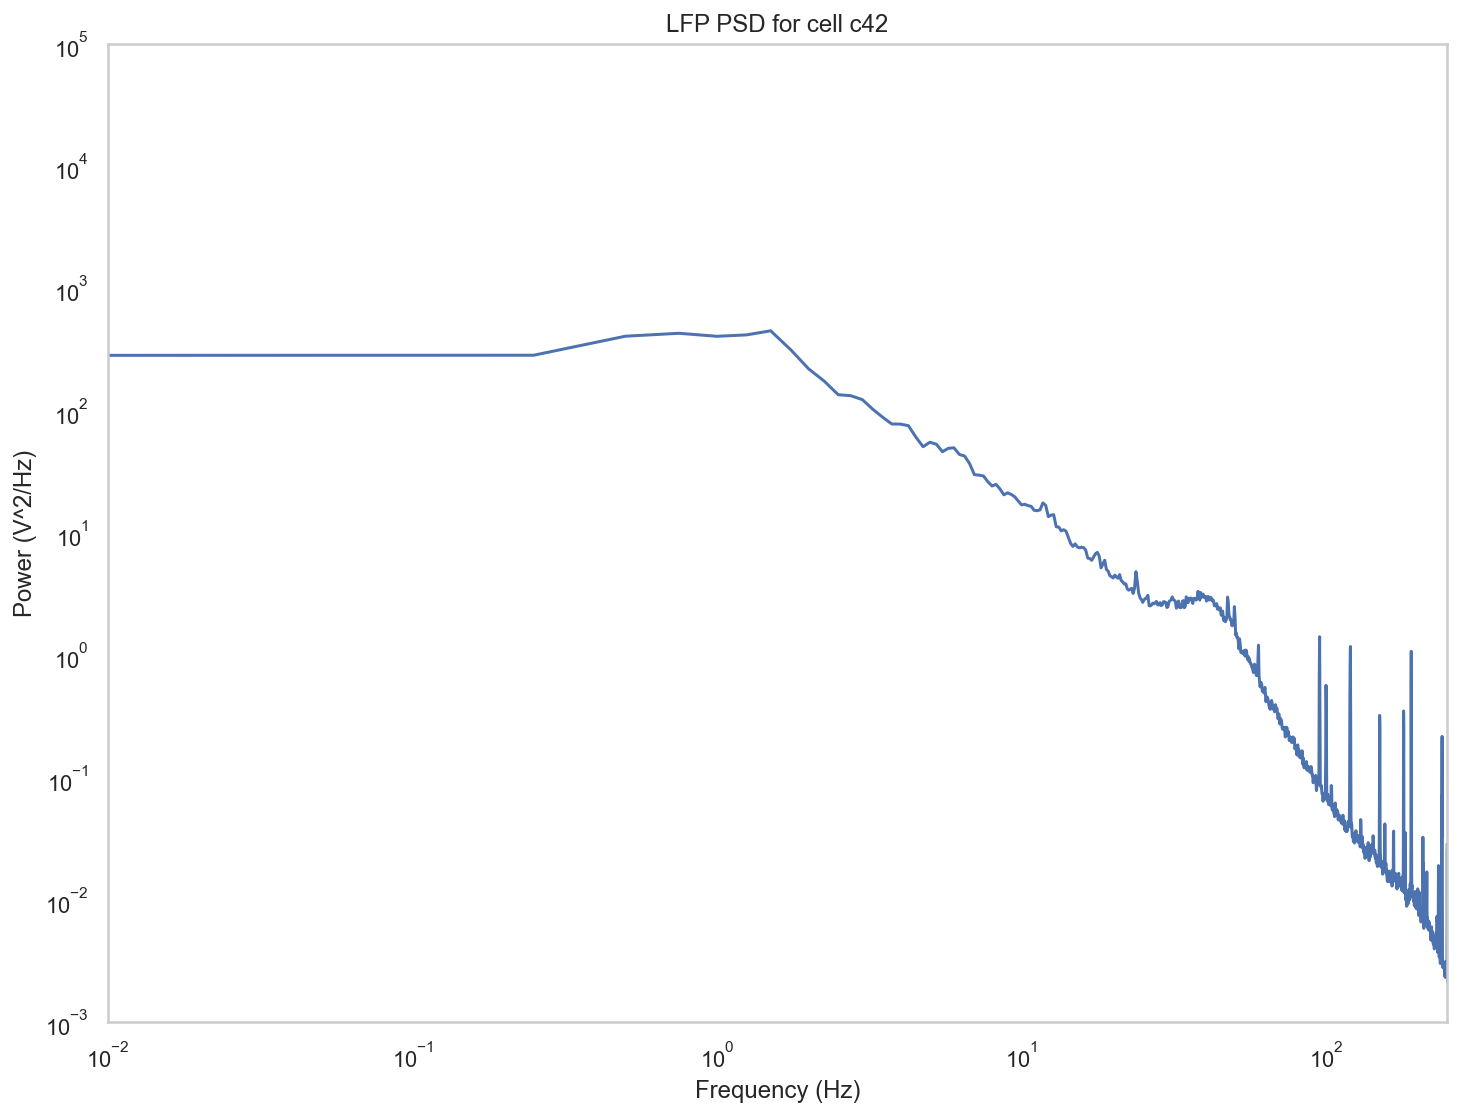

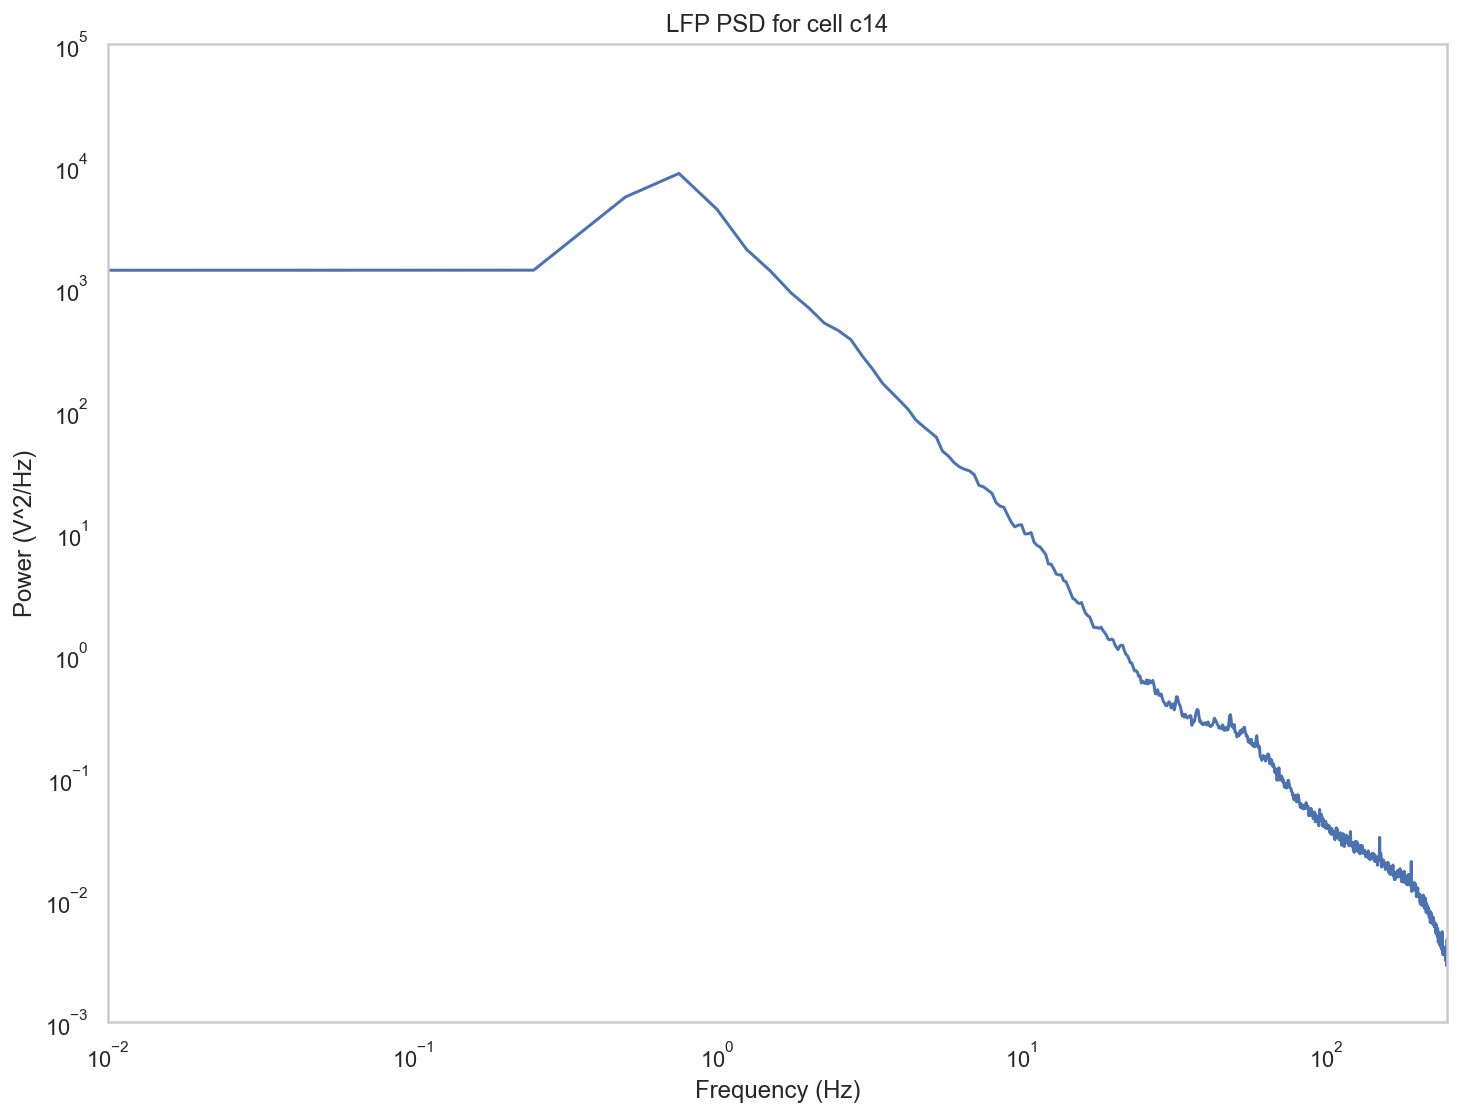

In [10]:
# open and load the data
filedir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings'


for filename in tqdm(os.listdir(filedir)):

    lfpfile = os.path.join(filedir, filename)

    if lfpfile.endswith('.npy'):
        #get cell number 
        cell_num = lfpfile.split('/')[len(lfpfile.split('/'))-1].split('_')[0]
        #patch_filt = np.load(filedir + 'patch_filt.npy')
        #npx_filt = np.load(filedir + 'npx_filt.npy')
        lfp_filt = np.load(lfpfile)

        #patch_fs = 50023.88925263
        #patch_one_ms = int(patch_fs / 1000)

        #npx_fs = 30000 # sampling rate
        #npx_one_ms = int(npx_fs / 1000)

        lfp_fs = 2500 # sampling rate
        lfp_one_ms = int(lfp_fs / 1000)

        #patch_times = np.arange(0, np.shape(patch_filt)[0]) / patch_one_ms # in ms instead of sec
        #npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec
        lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec
        
     
        # plot power spectrum
        fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

        xlim = (10e-3, 250)
        ylim = (10e-4, 10e4)
        plt.loglog(fxx, pxx)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (V^2/Hz)')
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.title("LFP PSD for cell "+ cell_num)
        plt.show()
